# A Hands-On Workshop: From Python Basics to Geospatial Mapping

---

| Section | Topics 
|---|---
| **Part 1A** | Python Fundamentals 
| **Part 1B** | Pandas & Datasets 
| **Part 1C** | Matplotlib
| **Part 2A** | Seaborn + Stats 
| **Part 2B** | GeoPandas & Shapefiles 
| **Part 2C** | WFS Feeds & Projections 
| **Part 2D** | Interactive Maps with Folium 
| **Part 2E** | Choropleth Maps & Professional Layouts 

---

> **Setup check:** Run the cell below to make sure your environment is ready.


In [56]:
# ✅ Environment Setup — Run this first!
# If any packages are missing, install them using pip before running the rest of the notebook.
# For example, run `%pip install numpy pandas matplotlib seaborn geopandas folium geodatasets mapclassify` in your terminal if you see any missing packages below.

import sys
required = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'geopandas', 'folium', 'geodatasets', 'mapclassify']
missing = []
for pkg in required:
    try:
        __import__(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        missing.append(pkg)
        print(f"  ✗ {pkg}  ← MISSING")

if missing:
    print(f"Install missing packages with:")
    print(f"  pip install {' '.join(missing)}")
else:
    print("\n🎉 All packages ready!")


  ✓ numpy
  ✓ pandas
  ✓ matplotlib
  ✓ seaborn
  ✓ geopandas
  ✓ folium
  ✓ geodatasets
  ✓ mapclassify

🎉 All packages ready!


---
# 🐍 Part 1A — Python Fundamentals

Python is a **general-purpose programming language** that has become the dominant tool in data science. It's readable, beginner-friendly, and has an enormous ecosystem of libraries.

Let's start from scratch.

---
## 1. Variables, Basic Data Types, and Control Structures

Note: a **variable** is a name that points to a value stored in memory. Python is *dynamically typed* — you don't declare types upfront.


In [8]:
# --- Numeric types ---
age = 25          # int (whole number)
gpa = 3.87        # float (decimal)
population = 500_000  # underscores make large numbers readable!

print(type(age), age)
print(type(gpa), gpa)
print(type(population), population)


<class 'int'> 25
<class 'float'> 3.87
<class 'int'> 500000


In [12]:
# --- Strings ---
city = "Iowa City"
state = 'Iowa'      # single or double quotes — both work
greeting = f"Welcome to {city}, {state}!"  # f-strings: embed variables directly
gsu_zipcode = 52242 # integer, but we can still use it in a string
gsuzip = f"GSU Campus is located in zipcode {gsu_zipcode}."

print(greeting)
print(gsuzip)
print(f"Length of city name: {len(city)} characters") # the len() function gives the number of characters in a string
print(f"Uppercase: {city.upper()}") # the upper() method converts a string to uppercase
print(f"Titlecase: {state.title()}") # the title() method converts a string to title case (first letter of each word capitalized)



Welcome to Iowa City, Iowa!
GSU Campus is located in zipcode 52242.
Length of city name: 9 characters
Uppercase: IOWA CITY
Titlecase: Iowa


In [17]:
# --- Booleans & None ---
is_enrolled = True
has_prerequisites = False
score = None    # None means "no value yet"

print(is_enrolled and has_prerequisites)   # AND — both must be True
print(is_enrolled or has_prerequisites)    # OR  — at least one True
print(not is_enrolled)                     # NOT — flips it

# Comparisons produce booleans
print(3 > 2)
print(10 == 10) # note: use == for comparison, not = which is assignment
print("Atlanta" != "Austin") # note the != operator means "not equal to"


False
True
False
True
True
True


In [20]:
# Conditionals 

# If-else statements
score = 85 # you can change this value to test different branches
if score >= 90: # note: the order of conditions matters!
    grade = 'A' # if score is 90 or above, grade is A
elif score >= 80: # if score is 80 or above (but less than 90), grade is B
    grade = 'B' 
elif score >= 70: # if score is 70 or above (but less than 80), grade is C
    grade = 'C'
else: # if score is below 70, grade is F (the "else" branch catches all remaining cases)
    grade = 'F' 
    
print(f"Score: {score}, Grade: {grade}")


Score: 85, Grade: B


In [28]:
# Loops
# For loops
print("For loop over a list:")
cities = ["Atlanta", "New York", "Los Angeles"] # a list of strings - more discussion below!
for city in cities: # loop variable "city" takes on each value in the list "cities"
    print(f"  - {city}")  # the loop body is indented (4 spaces) and runs once for each city

# For loops with range()
print("\nFor loop with range():")
for i in range(5): # range(5) generates the numbers 0, 1, 2, 3, 4
    print(f"  - Iteration {i}") # note: the loop variable "i" is commonly used for indices or counters

# While loops
print("\nWhile loop counting down:")
count = 5
while count > 0: # the loop continues as long as the condition is True
    print(f"  - Count: {count}")
    count -= 1 # decrement count by 1 each time (same as count = count - 1)
print("Blast off!")

# Clarification on when something should be inside the indented block of a loop or conditional:
# - Only the code that should be repeated (for loops) or conditionally executed (if statements) should be indented. 
# - For example, in the for loop over cities, only the print statement is indented because we want to print each city. 
# - If we had another print statement after the loop that should only run once, it would not be indented.       
cities = ["Atlanta", "New York", "Los Angeles"]
for city in cities:
    print(f"  - {city}") # this is inside the loop, so it runs for each city

print("All cities printed!") # this is outside the loop, so it runs only once after the loop is done





For loop over a list:
  - Atlanta
  - New York
  - Los Angeles

For loop with range():
  - Iteration 0
  - Iteration 1
  - Iteration 2
  - Iteration 3
  - Iteration 4

While loop counting down:
  - Count: 5
  - Count: 4
  - Count: 3
  - Count: 2
  - Count: 1
Blast off!
  - Atlanta
  - New York
  - Los Angeles
All cities printed!


## 2. Collections: Lists, Dictionaries, and Tuples

Real data comes in **collections**. Python has several built-in container types:

| Type | Syntax | Ordered? | Mutable? | Duplicates? |
|------|--------|----------|----------|-------------|
| `list` | `[1, 2, 3]` | ✓ | ✓ | ✓ |
| `tuple` | `(1, 2, 3)` | ✓ | ✗ | ✓ |
| `dict` | `{'key': val}` | ✓ | ✓ | keys: ✗ |
| `set` | `{1, 2, 3}` | ✗ | ✓ | ✗ |


In [25]:
# ── Lists ──────────────────────────────────────
temperatures = [72, 85, 91, 88, 76, 69, 95]

print("All temps:", temperatures)
print("First:", temperatures[0])          # indexing starts at 0!
print("Last:", temperatures[-1])          # -1 means last element
print("First three:", temperatures[:3])   # slicing
print("Every other:", temperatures[::2]) # step in slicing
print("Between index 2 and 5:", temperatures[2:6]) # slice from index 2 up to (but not including) index 6
print("Average:", sum(temperatures) / len(temperatures)) # the sum() function adds up all the numbers in the list, and len() gives the number of elements, so this calculates the average temperature

# Lists are mutable — you can change them
temperatures.append(101)   # add to end
temperatures.sort() # sort the list in place (modifies the original list)
print("Sorted:", temperatures)


All temps: [72, 85, 91, 88, 76, 69, 95]
First: 72
Last: 95
First three: [72, 85, 91]
Every other: [72, 91, 76, 95]
Between index 2 and 5: [91, 88, 76, 69]
Average: 82.28571428571429
Sorted: [69, 72, 76, 85, 88, 91, 95, 101]


In [36]:
# ── Dictionaries ──────────────────────────────
# Dictionaries store KEY → VALUE pairs. Think of a real dictionary:
# word (key) → definition (value)

student = {
    "name": "Alex Rivera",
    "major": "Computer Science",
    "gpa": 3.6,
    "courses": ["DATA 1501", "CS 2200", "MATH 2215"],
    "enrolled": True
}

print(student["name"]) # access value by key
print(student["courses"]) # access the list of courses
print(f"Taking {len(student['courses'])} courses") # you can also access values inside the dictionary using keys, and then apply functions like len() to them

# Add a new key
student["graduation_year"] = 2026
print("Updated:", student)


Alex Rivera
['DATA 1501', 'CS 2200', 'MATH 2215']
Taking 3 courses
Updated: {'name': 'Alex Rivera', 'major': 'Computer Science', 'gpa': 3.6, 'courses': ['DATA 1501', 'CS 2200', 'MATH 2215'], 'enrolled': True, 'graduation_year': 2026}


In [37]:
# ── Nested structures (like JSON / real data!) ──
cohort = [
    {"name": "Alex",  "score": 88, "city": "Atlanta"},
    {"name": "Maya",  "score": 94, "city": "Decatur"},
    {"name": "Jamal", "score": 79, "city": "Marietta"},
    {"name": "Priya", "score": 91, "city": "Atlanta"},
]

# Access nested data
print(cohort[1]["name"], "—", cohort[1]["score"])

# Get all scores
scores = [s["score"] for s in cohort]   # list comprehension!
print("Scores:", scores)


Maya — 94
Scores: [88, 94, 79, 91]


## 3. Control Flow: Loops and Conditionals Applied to Containers

**Control flow** determines *when* and *how often* code runs.


In [38]:
# ── if / elif / else ──────────────────────────
def letter_grade(score): # We are using a function here to encapsulate the logic of converting a numeric score to a letter grade, which makes it reusable and keeps our code organized.
    """Convert numeric score to letter grade."""
    if score >= 90:
        return "A"
    elif score >= 80:
        return "B"
    elif score >= 70:
        return "C"
    elif score >= 60:
        return "D"
    else:
        return "F"

for student in cohort:
    grade = letter_grade(student["score"]) # we call the letter_grade function with the student's score to get their letter grade
    print(f"  {student['name']:10s} → {student['score']} → {grade}")


  Alex       → 88 → B
  Maya       → 94 → A
  Jamal      → 79 → C
  Priya      → 91 → A


In [ ]:
# ── for loops ────────────────────────────────
# for loops iterate over any sequence

cities = ["Atlanta", "Decatur", "Marietta", "Sandy Springs"]

for i, city in enumerate(cities):   # enumerate provides a mechanism to get both the index and the value when looping over a list
    print(f"  {i+1}. {city}") # note the use of i+1 to start counting from 1 instead of 0 as the starting index in any list is 0

# List comprehension is commonly used to create new lists based on existing ones, often with some transformation or filtering applied. 
# It's a more concise and often more readable way to write loops that build lists alebit it can take some practice to get used to the syntax. 

# The general form of a list comprehension is: 
# new_list = [expression for item in iterable if condition] -- iterable here means any sequence you can loop over (like a list), 
# item is the loop variable that takes on each value in the iterable, expression is what gets evaluated for each item and 
# collected into the new list, and condition is an optional filter that determines which items are included in the new list.

# ── List comprehensions — compact loops that build lists ──
name_lengths = [len(city) for city in cities] # here city is the loop variable that takes on each value in cities, and len(city) is the expression that gets evaluated for each city and collected into the new list name_lengths
print("\nName lengths:", name_lengths)

long_names = [city for city in cities if len(city) > 7] # Similar to the previous list comprehension, but with an added condition (if len(city) > 7) that filters which cities are included in the new list long_names
print("Long names:", long_names)


  1. Atlanta
  2. Decatur
  3. Marietta
  4. Sandy Springs

Name lengths: [7, 7, 8, 13]
Long names: ['Marietta', 'Sandy Springs']


In [39]:
# ── while loops ──────────────────────────────
# while loops run as long as a condition is True (be careful — infinite loops!)

countdown = 5
while countdown > 0:
    print(f"  T-minus {countdown}...")
    countdown -= 1 # this update is crucial to eventually make the condition False and stop the loop; without it, countdown would always be 5 and the loop would run forever
print("  🚀 Launch!") # notice how this is placed "outside" the loop


  T-minus 5...
  T-minus 4...
  T-minus 3...
  T-minus 2...
  T-minus 1...
  🚀 Launch!


## 4. Functions

Functions are **reusable blocks of code**. Good functions:
- Do *one* thing well
- Have a clear name
- Accept inputs (parameters) and return outputs


In [40]:
# Basic function syntax
def celsius_to_fahrenheit(celsius): # def is the keyword to define a function, celsius_to_fahrenheit is the function name, and celsius is the parameter (input) that the function takes
    """Convert Celsius to Fahrenheit."""
    return (celsius * 9/5) + 32 # the return statement gives back a value to whoever called the function; in this case, it calculates the Fahrenheit equivalent of the Celsius input

# Functions can have default parameter values
def describe_temperature(celsius, unit="C"):
    f = celsius_to_fahrenheit(celsius)
    if unit == "F": # this checks if the caller wants the temperature described in Fahrenheit instead of Celsius - in that case, we return just the Fahrenheit value
        return f"(Input in F) {f:.1f}°F" # we can use string formatting to control how many decimal places to show (:.1f means 1 decimal place)
    return f"{celsius}°C ({f:.1f}°F)" # if the unit is not "F", we return the default description in Celsius along with the Fahrenheit equivalent in parentheses

# Test it
for temp in [0, 20, 37, 100]:
    print(describe_temperature(temp))



0°C (32.0°F)
20°C (68.0°F)
37°C (98.6°F)
100°C (212.0°F)


In [42]:
# Here is a more complex input where the data contains a combination of temperature value and its unit
# We use the function above and return the correct values depending on the unit specified
temps = ["0C", "20C", "37C", "100C", "32F", "212F"] # Values provided as strings with the last character indicating the unit (C for Celsius, F for Fahrenheit)
for t in temps:
    value = int(t[:-1]) # this takes all characters except the last one (the unit) and converts it to an integer
    unit = t[-1] # this takes the last character which is the unit (C or F)
    print(describe_temperature(value, unit)) # we call the describe_temperature function with the value and unit to get the correct description based on the unit specified

0°C (32.0°F)
20°C (68.0°F)
37°C (98.6°F)
100°C (212.0°F)
(Input in F) 89.6°F
(Input in F) 413.6°F


In [44]:
# ── 💡 Mini-Exercise 1 ──────────────────────────────────────────────────────
# Write a function `summarize_scores(scores_list)` that returns a dictionary
# with keys: 'mean', 'min', 'max'
# Then call it on: [78, 92, 85, 66, 91, 73, 88]


---
# 🐼 Part 1B — Pandas & Working with Datasets

**Pandas** is the workhorse of data science in Python. It gives you the `DataFrame` — a 2D table with labeled rows and columns — think of it as a supercharged spreadsheet inside Python.

```
pip install pandas
```


In [31]:
import numpy as np
import pandas as pd

# ── Loading data ─────────────────────────────────────────────────────────────
# Seaborn ships several classic datasets — perfect for learning
import seaborn as sns

df = sns.load_dataset("tips")   # restaurant tipping data
print(type(df))
print(df.shape)   # (rows, columns)


<class 'pandas.DataFrame'>
(244, 7)


In [46]:
# ── First look at the data ────────────────────────────────────────────────
df.head(8)   # first 8 rows


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4


In [47]:
df.info()   # data types, missing values, memory usage


<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [48]:
df.describe()   # statistical summary of numeric columns


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


### 📊 Statistical Concepts: Central Tendency & Spread

Before we plot anything, let's understand what these numbers *mean*:

| Statistic | What it measures | Python |
|-----------|-----------------|--------|
| **Mean** | "Average" — sum ÷ count. Sensitive to outliers. | `df.mean()` |
| **Median** | Middle value when sorted. Robust to outliers. | `df.median()` |
| **Std Dev** | Average distance from the mean. Spread. | `df.std()` |
| **IQR** | Q3 - Q1. Middle 50% of data. Robust spread. | `q75 - q25` |

> 🔑 **Key insight**: If mean >> median, the distribution is *right-skewed* (pulled by large outliers). This is extremely common in income, tip, and price data!


In [ ]:
# Compare mean vs median — detecting skew
print("=== Total Bill ===")
print(f"  Mean:   ${df['total_bill'].mean():.2f}")
print(f"  Median: ${df['total_bill'].median():.2f}")
print(f"  Std:    ${df['total_bill'].std():.2f}")
print(f"  Skew:   {df['total_bill'].skew():.3f}  (positive = right-skewed)")

print("\n=== Tip Amount ===")
print(f"  Mean:   ${df['tip'].mean():.2f}")
print(f"  Median: ${df['tip'].median():.2f}")
print(f"  Skew:   {df['tip'].skew():.3f}")

# IQR
q25 = df['total_bill'].quantile(0.25)
q75 = df['total_bill'].quantile(0.75)
print(f"\nBill IQR: ${q75 - q25:.2f}  (Q1=${q25:.2f} → Q3=${q75:.2f})")


=== Total Bill ===
  Mean:   $19.8
  Median: $17.80
  Std:    $8.90
  Skew:   1.133  (positive = right-skewed)

=== Tip Amount ===
  Mean:   $3.00
  Median: $2.90
  Skew:   1.465

Bill IQR: $10.78  (Q1=$13.35 → Q3=$24.13)


In [43]:
# ── Selecting & Filtering ────────────────────────────────────────────────────

# Select a column → returns a Series
bills = df['total_bill']
print("Type:", type(bills))
print(bills.head()) # head function works on Series too, showing the first 5 values along with their index


Type: <class 'pandas.Series'>
0    16.99
1    10.34
2    21.01
3    23.68
4    24.59
Name: total_bill, dtype: float64


In [33]:
# Select multiple columns → returns a DataFrame
df[['total_bill', 'tip', 'sex']].head() # you can also use the head function on a DataFrame to show the first 5 rows of the selected columns


,total_bill,tip,sex
0,16.99,1.01,Female
1,10.34,1.66,Male
2,21.01,3.50,Male
3,23.68,3.31,Male
4,24.59,3.61,Female


In [37]:
# Filter rows with boolean conditions
# Who tipped more than $5?
big_tippers = df[df['tip'] > 5] # this creates a boolean mask (a Series of True/False values) where the condition is True for rows where the tip is greater than 5, and then uses that mask to select only those rows from the DataFrame
#print(type(big_tippers)) # big_tippers is still a DataFrame, but it only contains the rows where the tip was greater than 5
print(f"Big tippers: {len(big_tippers)} out of {len(df)} ({len(big_tippers)/len(df)*100:.1f}%)")
big_tippers.head()


Big tippers: 18 out of 244 (7.4%)


,total_bill,tip,sex,smoker,day,time,size
23,39.42,7.58,Male,No,Sat,Dinner,4
44,30.40,5.60,Male,No,Sun,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
52,34.81,5.20,Female,No,Sun,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4


In [40]:
# Compound conditions: use & (and) | (or) — NOT 'and'/'or' with DataFrames!
dinner_big = df[(df['time'] == 'Dinner') & (df['tip'] > 5)] # the condition inside the brackets creates a boolean mask that is True for rows where the time is 'Dinner' AND the tip is greater than 5, and then we use that mask to select only those rows from the DataFrame
print(f"Dinner with big tips: {len(dinner_big)}")


Dinner with big tips: 15


In [42]:
# ── Groupby: the split-apply-combine pattern ─────────────────────────────
# This is one of the most powerful pandas patterns

# Split by day → compute mean tip per day
daily_tips = df.groupby('day')['tip'].agg(['mean', 'median', 'count']) # groupby('day') splits the data into groups based on the 
print(type(daily_tips)) # this is a DataFrame where the index is the unique values from the 'day' column, and the columns are 'mean', 'median', and 'count' which are the results of applying those aggregation functions to the 'tip' column for each group
# unique values in the 'day' column, and then agg(['mean', 'median', 'count']) applies those aggregation functions to the 'tip' column 
# for each group, resulting in a new DataFrame with the mean, median, and count of tips for each day
daily_tips.columns = ['Mean Tip', 'Median Tip', 'Count'] # here we are renaming the columns of the resulting DataFrame to be more descriptive (instead of 'mean', 'median', 'count', we have 'Mean Tip', 'Median Tip', 'Count')
daily_tips = daily_tips.sort_values('Mean Tip', ascending=False) # Finally, we sort the resulting DataFrame by the 'Mean Tip' column in descending order (highest mean tip first) to make it easier to see which day had the highest average tip
print(daily_tips)


<class 'pandas.DataFrame'>
      Mean Tip  Median Tip  Count
day                              
Sun   3.255132       3.150     76
Sat   2.993103       2.750     87
Thur  2.771452       2.305     62
Fri   2.734737       3.000     19


In [43]:
# Group by multiple columns
by_day_time = df.groupby(['day', 'time'])['total_bill'].mean().round(2) # notice that we are not using .agg() here, 
# but instead directly calling mean() on the grouped object, which gives us a Series with a MultiIndex (day, time) 
# and the mean total bill for each combination of day and time
print(type(by_day_time)) # this is a Series with a MultiIndex
print(by_day_time) # this shows the mean total bill for each combination of day and time, with a MultiIndex (day, time) 
print("\nUnstacked:")
print(by_day_time.unstack())   # unstack turns inner index into columns


# Here is an example of how unstack works 
# For example, if we have a Series with a MultiIndex like this:
# day   time
# Fri   Lunch    15.34
#       Dinner   20.45
# Sat   Lunch    14.56
#       Dinner   22.78
# the inner index here is "time" (Lunch, Dinner) and the outer index is "day" (Fri, Sat).
# unstack() would transform it into a DataFrame like this:
# time   Lunch  Dinner
# day
# Fri    15.34   20.45
# Sat    14.56   22.78



<class 'pandas.Series'>
day   time  
Thur  Lunch     17.66
      Dinner    18.78
Fri   Lunch     12.85
      Dinner    19.66
Sat   Dinner    20.44
Sun   Dinner    21.41
Name: total_bill, dtype: float64

Unstacked:
time  Lunch  Dinner
day                
Thur  17.66   18.78
Fri   12.85   19.66
Sat     NaN   20.44
Sun     NaN   21.41


In [60]:
# ── Creating new columns ──────────────────────────────────────────────────
df['tip_pct'] = df['tip'] / df['total_bill'] * 100 # here df[tip_pct] creates a new column in the DataFrame called 'tip_pct', and we assign it the value of the tip amount divided by the total bill, multiplied by 100 to get a percentage
print(df[['total_bill', 'tip', 'tip_pct']].head()) # we can now see the new column 'tip_pct' alongside the original 'total_bill' and 'tip' columns

   total_bill   tip    tip_pct
0       16.99  1.01   5.944673
1       10.34  1.66  16.054159
2       21.01  3.50  16.658734
3       23.68  3.31  13.978041
4       24.59  3.61  14.680765


In [76]:
# ── 💡 Mini-Exercise 2 ──────────────────────────────────────────────────────
# 1. What is the average tip percentage for male vs female payers?
# 2. On which day did the restaurant have the highest average party size?
#


---
# 📈 Part 1C — Matplotlib Fundamentals

**Matplotlib** is the foundational plotting library in Python. Almost every other plotting library (Seaborn, GeoPandas, etc.) is built on top of it.

### The anatomy of a Matplotlib figure

```
Figure  ← the whole canvas
  └── Axes  ← one plot area (you can have multiple)
        ├── x-axis / y-axis
        ├── title, labels
        └── plot elements (lines, bars, points...)
```

There are two ways to use matplotlib:
- **pyplot style** (`plt.plot(...)`) — quick and easy
- **object-oriented style** (`fig, ax = plt.subplots()`) — more control ✅ *prefer this*


In [53]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd 

# Good default settings for presentations
plt.rcParams['figure.dpi'] = 300 # higher DPI means sharper images, especially on high-res screens
plt.rcParams['font.family'] = 'sans-serif' # use a clean, modern font for better readability in presentations
plt.rcParams['axes.spines.top'] = False # this removes the top border line around the plot for a cleaner look
plt.rcParams['axes.spines.right'] = False # this removes the right border line around the plot for a cleaner look

print(f"Matplotlib version: {mpl.__version__}")


Matplotlib version: 3.10.8


   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
Name: passengers, dtype: int64
   year  passengers
0  1949        1520
1  1950        1676
2  1951        2042
3  1952        2364
4  1953        2700
[3363.58333333 3363.58333333 3363.58333333 3363.58333333 3363.58333333
 3363.58333333 3363.58333333 3363.58333333 3363.58333333 3363.58333333
 3363.58333333 3363.58333333]


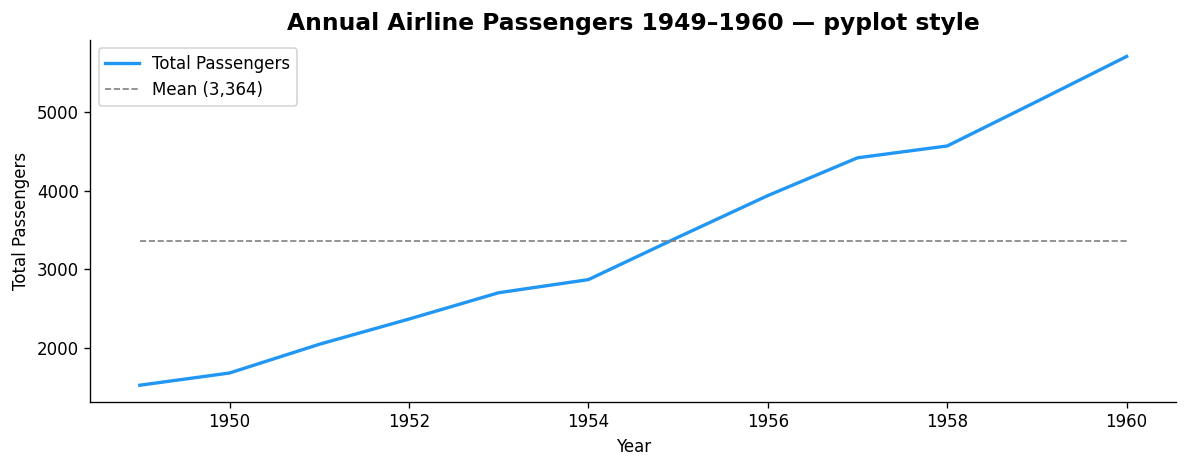

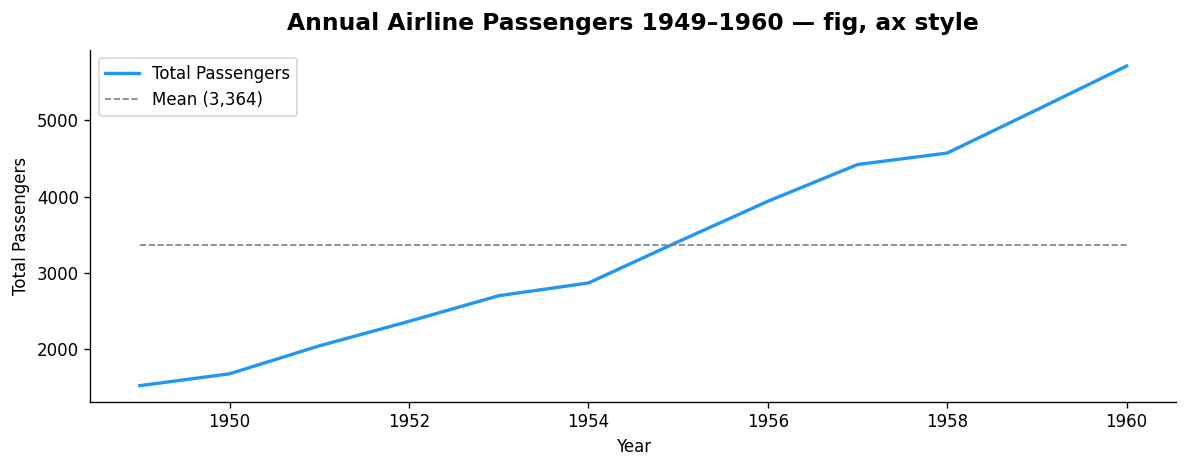

In [50]:
# ── Line Plot — trends over a sequence ──────────────────────────────────────
# A line plot is ideal for data that changes over a continuous sequence — most
# commonly time. The x-axis represents the sequence (year), the y-axis the value.

# The 'flights' dataset records monthly airline passenger counts from 1949–1960.
# We aggregate to yearly totals to keep one data point per x position.
flights = sns.load_dataset("flights")
print(flights.head())
yearly = flights.groupby("year")["passengers"].sum()
print(yearly.head())
yearly = yearly.reset_index() # reset_index() turns the "year" index back into a regular 
# column after grouping
print(yearly.head())


years    = yearly["year"].values         # x-axis: years 1949–1960
revenue  = yearly["passengers"].values   # y-axis: total passengers that year
baseline = np.full(len(years), yearly["passengers"].mean())  # np.full creates an array of the same length as years, 
print(baseline)
# filled with the mean passenger count, which we will use as a baseline for comparison in the plot


# ════════════════════════════════════════════════════════════════════════════════
# EXAMPLE 1 — pyplot style  (simple, implicit)
# ════════════════════════════════════════════════════════════════════════════════
# The pyplot interface (plt.*) maintains a hidden "current figure" behind the scenes.
# Every plt.* call automatically targets that figure — you never need to reference
# it directly. This makes it fast to write, but harder to control precisely.
# ✅ Good for: quick exploratory plots
# ⚠️  Avoid for: complex layouts, multiple subplots, or reusable functions

plt.figure(figsize=(10, 4))  # create a new figure; width=10", height=4"

# plt.plot(x, y) connects data points with a line in the order they appear.
# Key styling arguments:
#   color     — hex code, named color ('red'), or RGB tuple ((0.1, 0.5, 0.9))
#   linewidth — thickness of the line in points
#   linestyle — '-' solid  '--' dashed  ':' dotted  '-.' dash-dot
#   label     — text shown in the legend for this line
plt.plot(years, revenue,  color='#2196F3', linewidth=2, linestyle='-',  label='Total Passengers')
plt.plot(years, baseline, color='gray',    linewidth=1, linestyle='--', label=f'Mean ({baseline[0]:,.0f})')

plt.title('Annual Airline Passengers 1949–1960 — pyplot style', fontsize=14, fontweight='bold')
plt.xlabel('Year')             # always label your axes — a chart without labels forces the reader to guess
plt.ylabel('Total Passengers')
plt.legend()                   # draws the legend using each line's label= string

plt.tight_layout()  # automatically adjusts padding so titles/labels aren't clipped
plt.show()


# ════════════════════════════════════════════════════════════════════════════════
# EXAMPLE 2 — fig, ax style  (explicit, recommended)
# ════════════════════════════════════════════════════════════════════════════════
# plt.subplots() returns two objects you hold explicit references to:
#   fig → the entire canvas  (size, background color, saving to file)
#   ax  → the plot area      (lines, axes, labels, ticks, annotations)
#
# Because you have direct handles, this style scales naturally:
#   one panel:   fig, ax = plt.subplots()
#   two panels:  fig, (ax1, ax2) = plt.subplots(1, 2)
#   grid:        fig, axes = plt.subplots(2, 3)

fig, ax = plt.subplots(figsize=(10, 4))

# ax.plot() is identical in behavior to plt.plot() — same arguments, same result.
# The only difference is it explicitly targets this axes object rather than
# relying on matplotlib's hidden "current figure" state.
ax.plot(years, revenue,  color='#2196F3', linewidth=2, linestyle='-',  label='Total Passengers')
ax.plot(years, baseline, color='gray',    linewidth=1, linestyle='--', label=f'Mean ({baseline[0]:,.0f})')

# Most methods gain a set_* prefix compared to pyplot:
#   plt.title()  →  ax.set_title()     plt.xlabel()  →  ax.set_xlabel()
#   plt.ylabel() →  ax.set_ylabel()    plt.legend()  →  ax.legend()  (no prefix change)
# pad= adds extra space between the title text and the top edge of the plot area
ax.set_title('Annual Airline Passengers 1949–1960 — fig, ax style', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Total Passengers')
ax.legend()

plt.tight_layout()
plt.show()


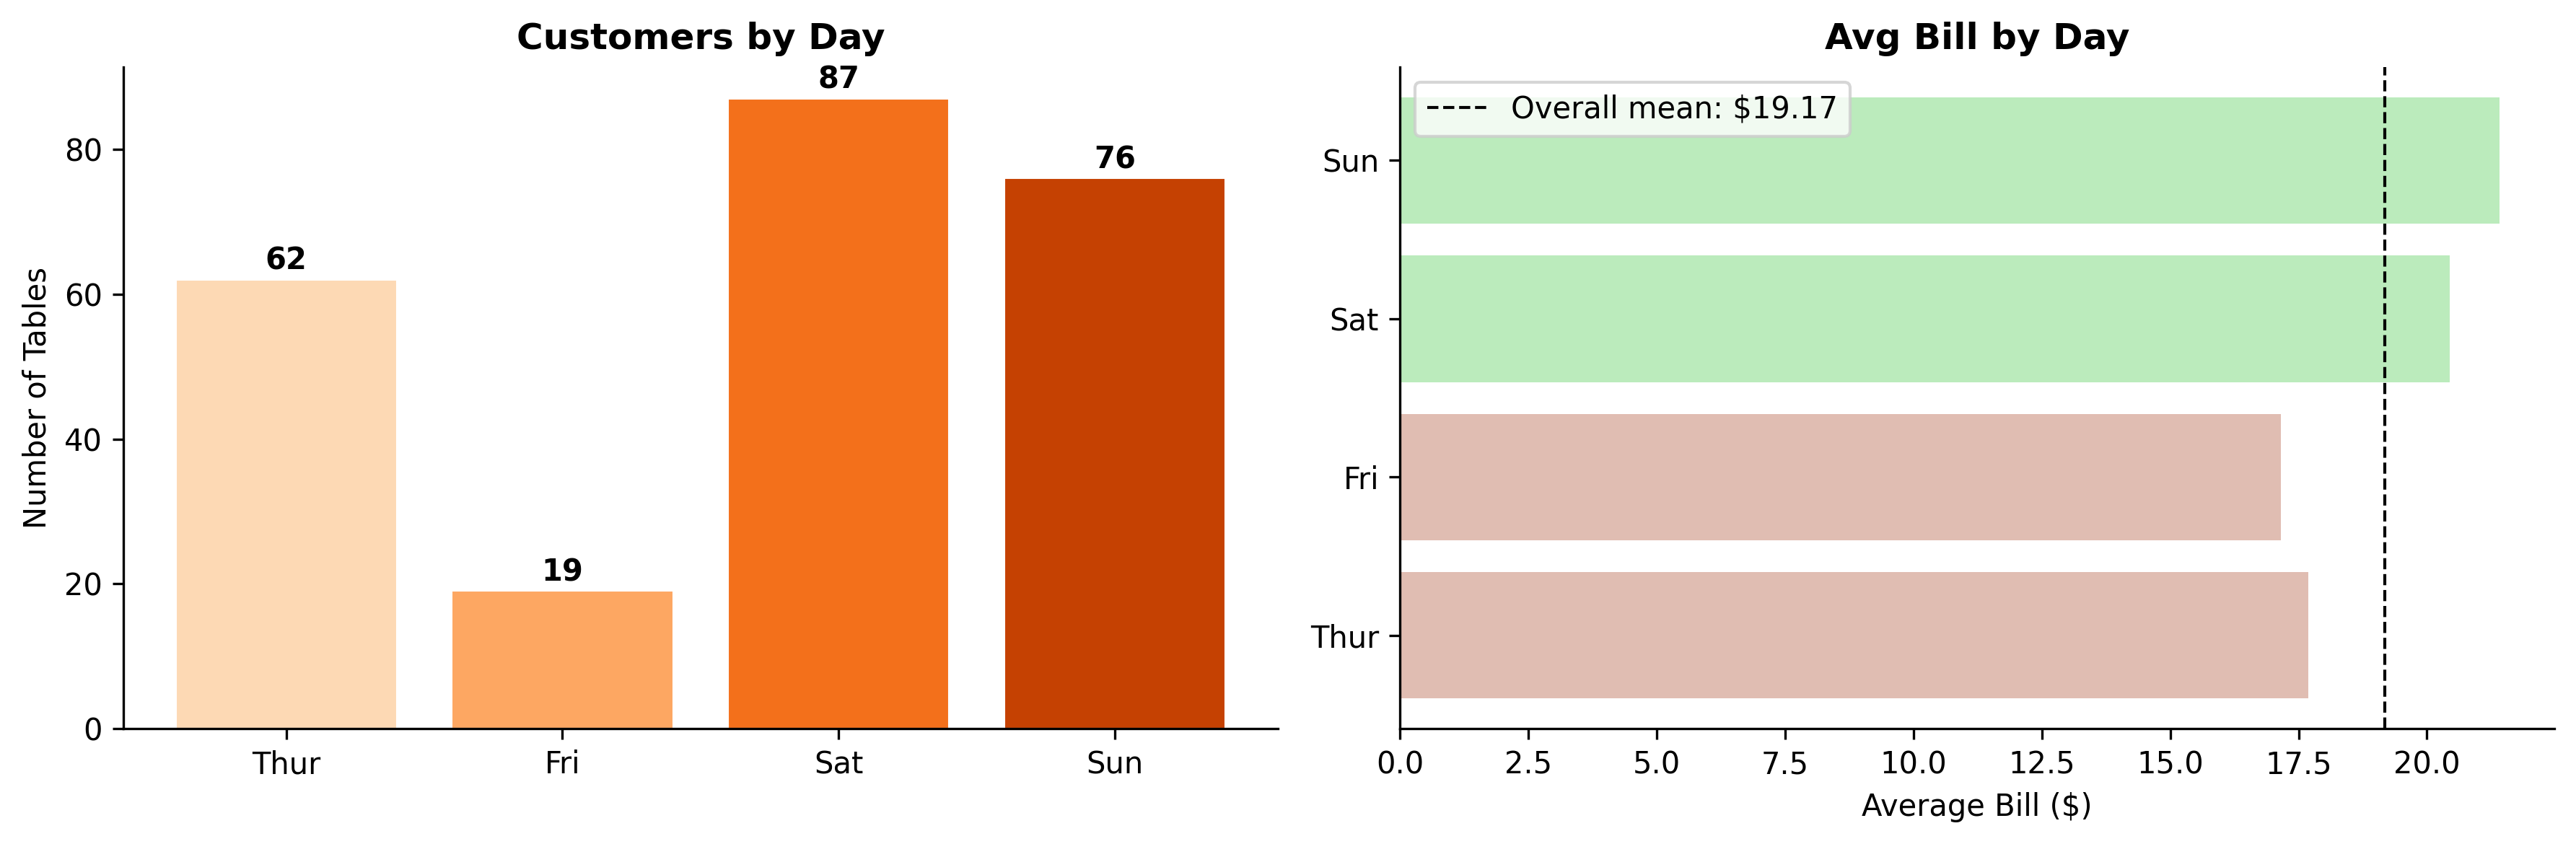

In [58]:
# ── Bar Chart — comparing categories ────────────────────────────────────────
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
day_counts = df['day'].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # use subplots to create a 1-row, 2-column layout and get explicit references 
# to each axes in the array "axes"


# Left: simple bar
axes[0].bar(day_counts.index, day_counts.values, # axes[0] targets the first subplot (left), and we use the bar() method to create a bar chart 
            # with the categories on the x-axis and their counts on the y-axis
            # use an existing color palette to automatically assign colors based on the number of bars
            color = sns.color_palette('Oranges', n_colors=len(day_counts)),
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Customers by Day', fontweight='bold')
axes[0].set_ylabel('Number of Tables')

# Add value labels on bars
for i, (day, count) in enumerate(day_counts.items()):
    axes[0].text(i, count + 0.5, str(count), ha='center', va='bottom', fontweight='bold')
    # line above: the bar (y=count + 0.5) with the count value as text, centered horizontally (ha='center') 
    # and aligned to the bottom of the text (va='bottom') so it appears just above the bar, and with bold font for better visibility

# Right: horizontal bar (better for many categories)
avg_bill_day = df.groupby('day')['total_bill'].mean().reindex(day_order)
colors = ["#BBEBBC" if v > avg_bill_day.mean() else "#E0BDB2" for v in avg_bill_day]

axes[1].barh(avg_bill_day.index, avg_bill_day.values, color=colors)
axes[1].axvline(avg_bill_day.mean(), color='black', linestyle='--', 
                linewidth=1, label=f'Overall mean: ${avg_bill_day.mean():.2f}') # this adds a vertical line at the overall mean 
                #average bill across all days, with a label that shows the mean value formatted as currency
axes[1].set_title('Avg Bill by Day', fontweight='bold')
axes[1].set_xlabel('Average Bill ($)')
axes[1].legend()

plt.tight_layout()
plt.show()


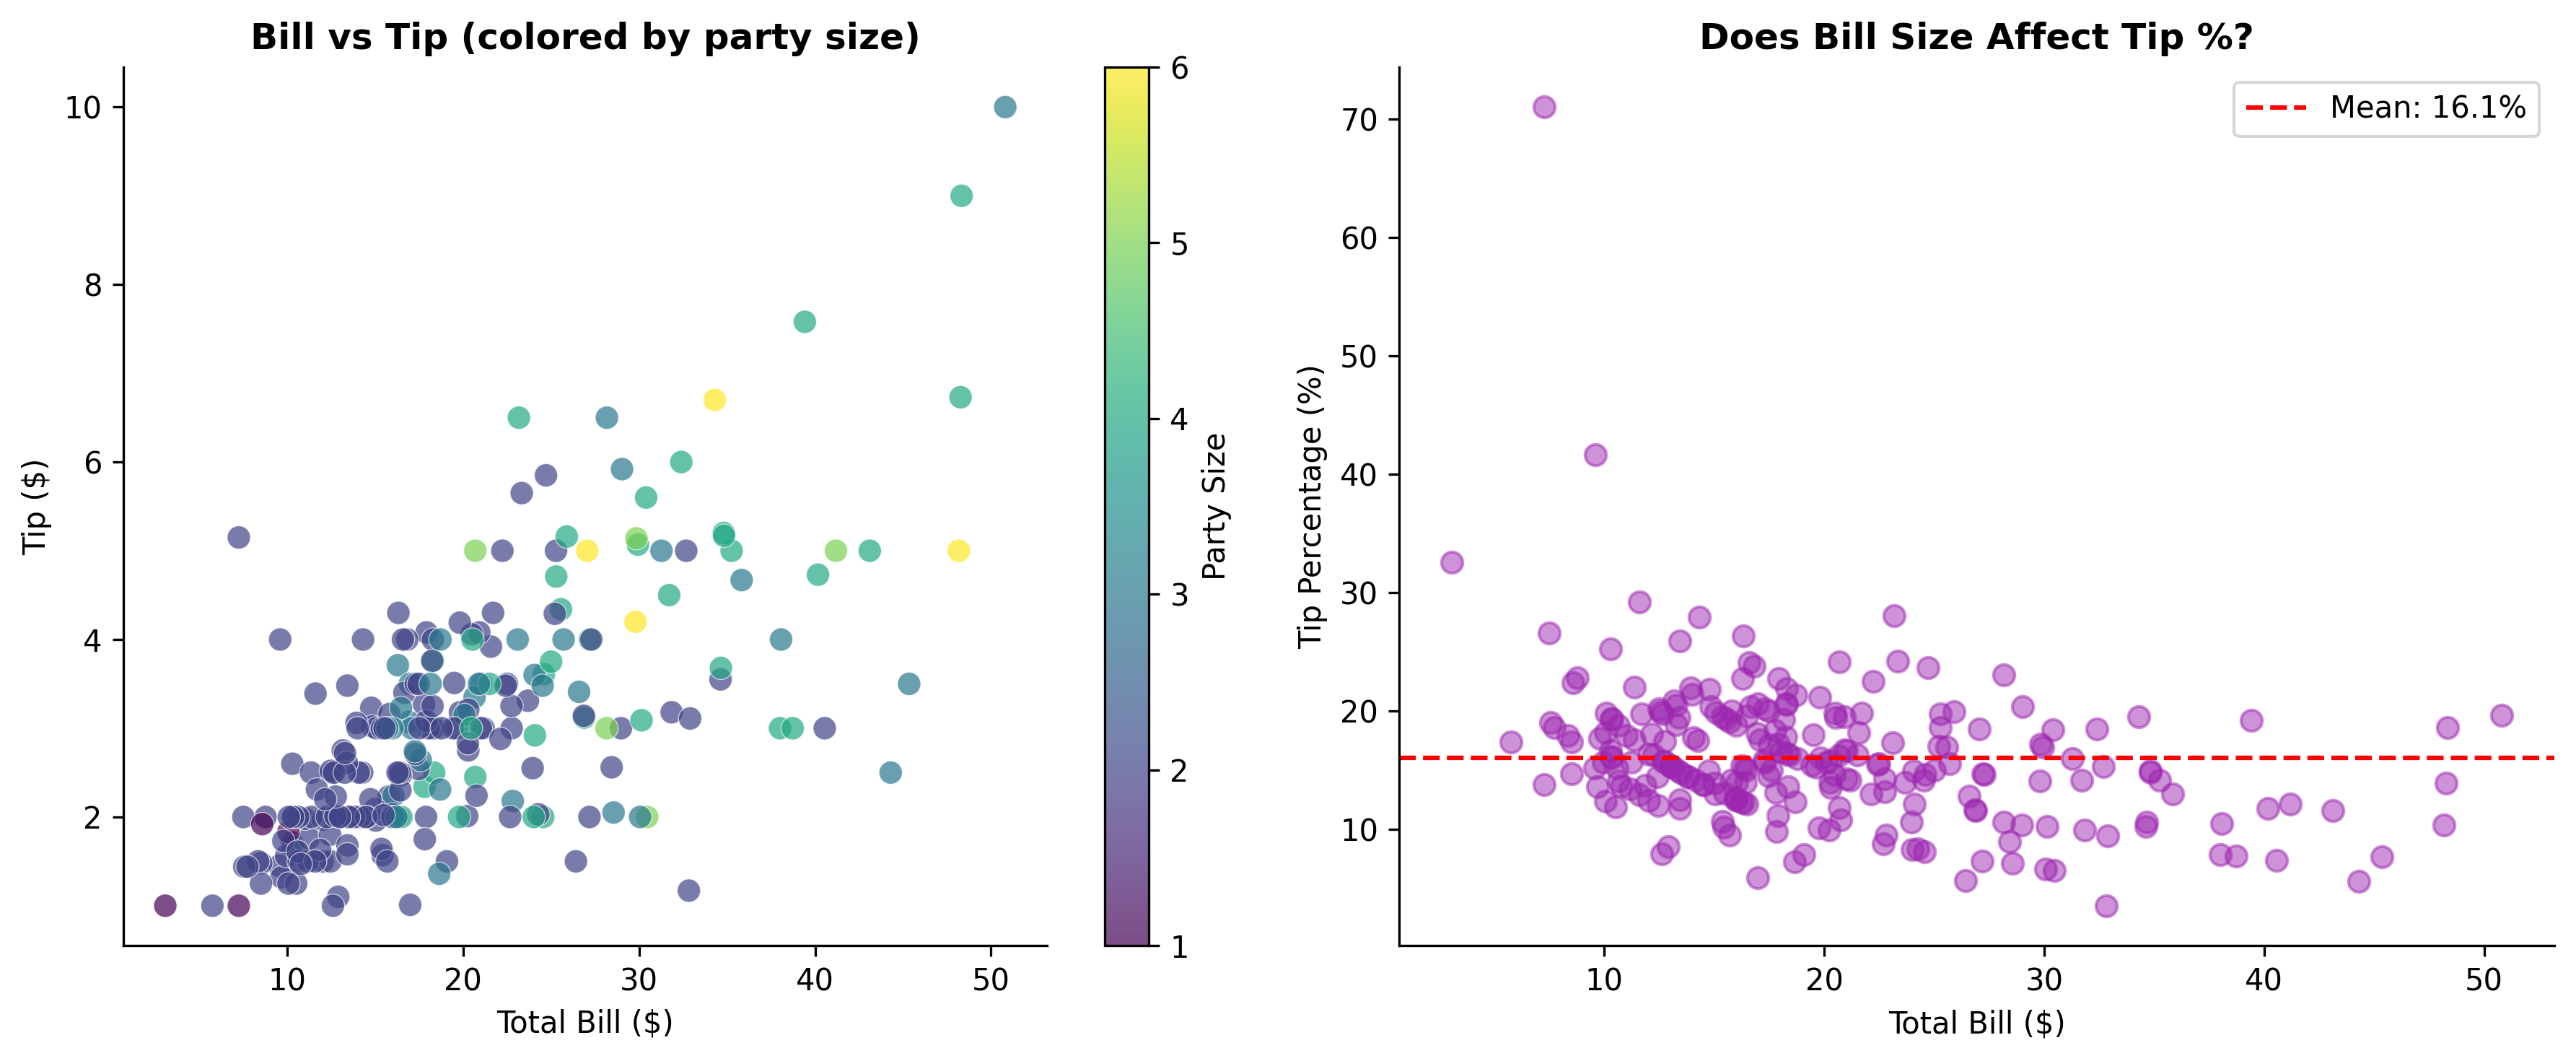

In [61]:
# ── Scatter Plot — relationships between two numeric variables ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: basic scatter
scatter = axes[0].scatter(df['total_bill'], df['tip'],
                           c=df['size'], cmap='viridis',
                           alpha=0.7, s=60, edgecolors='white', linewidth=0.3)
# Line above: creates a scatter plot on axes[0] with total_bill on the x-axis and tip on the y-axis,
# where the color of each point (c=) is determined by the 'size' column, using the 'viridis' colormap to map size values to colors. 
# The points are semi-transparent (alpha=0.7) to help with overplotting, sized at 60, and have white edges for better visibility 
# against the background.
plt.colorbar(scatter, ax=axes[0], label='Party Size')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip ($)')
axes[0].set_title('Bill vs Tip (colored by party size)', fontweight='bold')

# Right: scatter with annotations
axes[1].scatter(df['total_bill'], df['tip_pct'], alpha=0.5, color='#9C27B0', s=50)
axes[1].axhline(df['tip_pct'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["tip_pct"].mean():.1f}%') # add a horizontal line at the mean tip percentage with a label 
                #showing the mean value formatted as a percentage
axes[1].set_xlabel('Total Bill ($)')
axes[1].set_ylabel('Tip Percentage (%)')
axes[1].set_title('Does Bill Size Affect Tip %?', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()




### 📊 Statistical Concept: Correlation

The **Pearson correlation coefficient (r)** ranges from -1 to +1:

| Value | Interpretation |
|-------|---------------|
| r ≈ +1 | Perfect positive linear relationship |
| r ≈ 0 | No linear relationship |
| r ≈ -1 | Perfect negative linear relationship |

> ⚠️ **Correlation ≠ Causation!** Two variables can be correlated without one causing the other.
> Famous example: ice cream sales and drowning deaths are positively correlated (both driven by summer heat).


In [24]:
# Correlation coefficient
r = df['total_bill'].corr(df['tip'])
print(f"Pearson correlation (bill vs tip): r = {r:.3f}")
print(f"Interpretation: {'strong' if abs(r)>0.7 else 'moderate' if abs(r)>0.4 else 'weak'} positive relationship")

Pearson correlation (bill vs tip): r = 0.676
Interpretation: moderate positive relationship


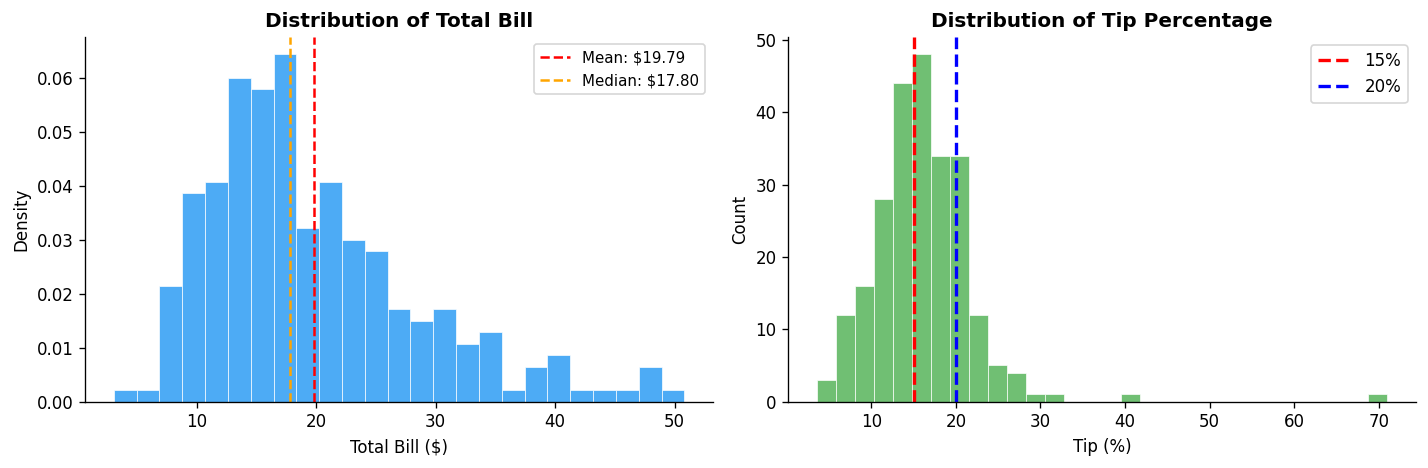

In [27]:
# ── Histogram — understanding distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bill distribution
axes[0].hist(df['total_bill'], bins=25, color='#2196F3', edgecolor='white', 
             linewidth=0.5, density=True, alpha=0.8)

# Mark mean and median
axes[0].axvline(df['total_bill'].mean(), color='red', linestyle='--', 
                label=f'Mean: ${df["total_bill"].mean():.2f}', linewidth=1.5)
axes[0].axvline(df['total_bill'].median(), color='orange', linestyle='--', 
                label=f'Median: ${df["total_bill"].median():.2f}', linewidth=1.5)
axes[0].set_title('Distribution of Total Bill', fontweight='bold')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Right: tip percentage
axes[1].hist(df['tip_pct'], bins=30, color='#4CAF50', edgecolor='white', linewidth=0.5, alpha=0.8)
axes[1].axvline(15, color='red', linestyle='--', linewidth=2, label='15%')
axes[1].axvline(20, color='blue', linestyle='--', linewidth=2, label='20%')
axes[1].set_title('Distribution of Tip Percentage', fontweight='bold')
axes[1].set_xlabel('Tip (%)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()
